### Key Concepts

##### Generative AI vs Agentic AI

| | Generative AI | Agentic AI |
| --- | --- | --- |
| **Type** | Reactive | Proactive |
| **Sequence** | Prompt → Generate | Prompt → Action |
| **Outcome** | Generate Text, Images, Code, Files, Music | Perceives → Decide → Execute → Learn |
| **Purpose** | Helps with the task of content creation. Human Reviews, Refine and Direct in each step. | Goes further by planning, using tools, and taking multi-step actions to achieve goals. The multi-step process rides on the Chain-of-Thought processing to explore problem space before an execution |

##### LangChain (Generative AI) vs LangGraph (Agentic AI)

| Aspect | LangChain | LangGraph |
|---|---|---|
| Core purpose and ideal use | Build LLM apps quickly with reusable components for straightforward to moderately complex flows | Build robust agent systems with explicit control over complex, branching, multi-step workflows |
| Execution and control style | Primarily chain-oriented and sequential, with some agent support | Graph-based execution with native loops, branches, and fine-grained flow control |
| State and memory model | Basic memory patterns and component-level state passing | First-class persistent state across nodes and steps |
| Reliability and production readiness | Fast to prototype, but complex control logic can get harder to manage | Better suited for deterministic orchestration, recovery, and long-running production agents |
| Learning curve and adoption path | Easier to learn and faster to start | More setup and concepts, but stronger for advanced agent architectures |


##### Langchain

LangGraph is a framework for building AI agents that can plan and act through graph-based workflows. It breaks complex goals into connected steps, making execution order and logic explicit, so you can build structured, adaptable assistants for both simple automations and complex problem-solving.

##### LangGraph

LangGraph offers unique advantages for building intelligent AI agents, especially when compared to frameworks such as LangChain. One of its standout features is the ability to create **cyclic graphs** in addition to Directed Acyclic Graphs (DAGs). Here's why that matters:  

1. **Support for cyclic graphs:** LangGraph supports loops, so workflows can revisit earlier steps for retries, refinement, or feedback.  
2. **Not limited to one-way flows:** Unlike strict DAG-only designs, it can handle iterative paths when tasks need multiple passes.  
3. **Greater workflow flexibility:** Agents can adapt dynamically by reevaluating and repeating steps as conditions change.  
4. **Stronger iterative execution:** Well-suited for optimization, data refinement, and real-time adjustment workflows.  
5. **More versatile orchestration:** Combines structured DAG-style flows with loop-based agent behavior in one framework.

In [13]:
%pip install -q langgraph langchain --break-system-packages

Note: you may need to restart the kernel to use updated packages.


In [14]:
from langgraph.graph import StateGraph
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv

load_dotenv()

import os

llm = ChatOpenAI(
    api_key=os.environ["HUGGINGFACEHUB_API_TOKEN"],
    base_url="https://router.huggingface.co/v1",
    model="Qwen/Qwen3.5-397B-A17B:novita"
)

### Components of LangGraph

LangGraph’s strength lies in its structured and intuitive design, composed of essential building blocks that enable the creation of intelligent AI agents, with default stages denoting start and end of workflow.

<div style="text-align: center;">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/dhl478pwbZzrxzmcjJY4xw/Screenshot%202024-12-20%20at%204-19-46%E2%80%AFPM.png" alt="Screenshot" width="300">
</div>

### 1. States  
States store the workflow’s current context as data moves between nodes, such as user input, query results, or process status.  

Example: `AuthState` (`TypedDict` with optional fields) defines a type-safe auth context:
- `username: Optional[str]`
- `password: Optional[str]`
- `is_authenticated: Optional[bool]`
- `output: Optional[str]`  

This keeps state structure consistent while allowing missing values (`None`).

In [15]:
from typing import TypedDict, Optional

class AuthState(TypedDict):
    username: Optional[str] 
    password: Optional[str]
    is_authenticated: Optional[bool]
    output: Optional[str]

##### Example Objects and Their States

**Object 1: Successful Login**

Here is an example of the  ```AuthState ``` object  with a successful login:

In [16]:
auth_state_1: AuthState = {
    "username": "alice123",
    "password": "123",
    "is_authenticated": True,
    "output": "Login successful."
}
print(f"auth_state_1: {auth_state_1}")

auth_state_1: {'username': 'alice123', 'password': '123', 'is_authenticated': True, 'output': 'Login successful.'}


**Object 2: Unsuccessful Login**

Here is an example of the  ```AuthState ``` object with an unsuccessful login:


In [17]:
auth_state_2: AuthState = {
    "username":"",
    "password": "wrongpassword",
    "is_authenticated": False,
    "output": "Authentication failed. Please try again."
}
print(f"auth_state_2: {auth_state_2}")

auth_state_2: {'username': '', 'password': 'wrongpassword', 'is_authenticated': False, 'output': 'Authentication failed. Please try again.'}


This state serves as the backbone for workflows involving user authentication. It will be passed between nodes in a graph to validate the credentials and update the `is_authenticated` field accordingly.

### 2. Nodes  

Nodes are the **core units of action** in LangGraph. Each node represents a specific task or operation that the AI agent needs to perform. It can vary in complexity, from simple calculations to executing intricate workflows, and they form the foundation of any graph in LangGraph. 

<div style="text-align: center;">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/QPsWYzaKkacLUn8V1SbyWA/Screenshot%202024-12-20%20at%204-19-46%E2%80%AFPM%20copy-mh.png" alt="Screenshot" width="300">
</div>

##### Defining the Input Node

Now we define the `input_node`, which collects the user's username and password if they are not already provided in the state. This node ensures that the state is populated with the necessary input for authentication.

This node is usually the starting point in the graph, ensuring that the required input data is gathered before proceeding to the authentication step.

In [18]:
def input_node(state):
    print(state)
    if state.get('username', "") =="":
        state['username'] = input("What is your username?")

    password = input("Enter your password: ")

    return {"password":password}

In [19]:
input_node(auth_state_1)

{'username': 'alice123', 'password': '123', 'is_authenticated': True, 'output': 'Login successful.'}


{'password': ''}

In [20]:
input_node(auth_state_2)

{'username': '', 'password': 'wrongpassword', 'is_authenticated': False, 'output': 'Authentication failed. Please try again.'}


{'password': ''}

In this example, since there is no username provided, the function prompts us to enter one.

##### Defining the Validate Credentials Node

<div style="text-align: center;">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/OI9x1j0MXYtlsjdGGPemqA/Screenshot%202024-12-20%20at%204-19-46%E2%80%AFPM%20copy-mh%20-1-.png" alt="Screenshot" width="300">
</div>

A node is one workflow step that takes input state, performs logic, and returns updated state.  
`validate_credentials_node` checks `username` and `password`, sets `is_authenticated`, and returns the updated state so the graph can route to the next step based on auth success or failure.

In [21]:
def validate_credentials_node(state):
    # Extract username and password from the state
    username = state.get("username", "")
    password = state.get("password", "")

    print("Username :", username, "Password :", password)
    # Simulated credential validation
    if username == "test_user" and password == "secure_password":
        is_authenticated = True
    else:
        is_authenticated = False

    # Return the updated state with authentication result
    return {"is_authenticated": is_authenticated}


We can apply ```validate_credentials_node``` to two objects: one with an incorrect format and another with a correct format, to test its functionality.

**Incorrect Format**


In [22]:
validate_credentials_node(auth_state_1)

Username : alice123 Password : 123


{'is_authenticated': False}

**Correct Format**

In [23]:
auth_state_3: AuthState = {
    "username":"test_user",
    "password":  "secure_password",
    "is_authenticated": False,
    "output": "Authentication failed. Please try again."
}
print(f"auth_state_3: {auth_state_3}")

auth_state_3: {'username': 'test_user', 'password': 'secure_password', 'is_authenticated': False, 'output': 'Authentication failed. Please try again.'}


In [24]:
validate_credentials_node(auth_state_3)

Username : test_user Password : secure_password


{'is_authenticated': True}

##### Defining the Success Node  

<div style="text-align: center;">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/PwwDttqbSAwfrYvOQP2X-A/Screenshot%202024-12-20%20at%204-19-46%E2%80%AFPM%20copy-mh%20-2-.png" alt="Screenshot" width="300">
</div>


The `success_node` takes the current state as input and is triggered when the authentication process is successful. It returns a success message to indicate that the user has been authenticated.


In [25]:
# Define the success node
def success_node(state):
    return {"output": "Authentication successful! Welcome."}

In [26]:
success_node(auth_state_3)

{'output': 'Authentication successful! Welcome.'}

##### Defining the Failure Node 

<div style="text-align: center;">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/69hJU9b_hk_UNARWJW6IEw/Screenshot%202024-12-20%20at%204-19-46%E2%80%AFPM%20copy-mh%20-3-.png" alt="Screenshot" width="300">
</div>


The `failure_node` takes the current state as input and is triggered when the authentication process fails. It returns an output indicating the failure to authenticate.



In [27]:
# Define the failure node
def failure_node(state):
    return {"output": "Not Successfull, please try again!"}

##### Defining the Router Node  

<div style="text-align: center;">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/FpW7oG5oTxIPsaOqpxT7ow/Screenshot%202024-12-20%20at%204-19-46%E2%80%AFPM%20copy-mh%20-4-.png" alt="Screenshot" width="300">
</div>


The `router` node acts as a decision-making point in the workflow. It takes the current state as input and determines the next node to execute based on the `is_authenticated` value in the state.


In [28]:
def router(state):
    if state['is_authenticated']:
        return "success_node"
    else:
        return "failure_node"

This node ensures that the graph transitions to the appropriate node—either the success or failure node—based on whether the authentication was successful. It is an essential part of managing conditional logic in the workflow.


##### Creating the Graph  


In [29]:
from langgraph.graph import StateGraph
from langgraph.graph import END

# Create an instance of StateGraph with the GraphState structure
workflow = StateGraph(AuthState)
workflow

##### Adding Nodes to the Graph  

In [30]:
workflow.add_node("InputNode", input_node)
workflow.add_node("ValidateCredential", validate_credentials_node)
workflow.add_node("Success", success_node)
workflow.add_node("Failure", failure_node)

### 3. Edges

Edges define the **connections between nodes** and represent the flow of execution within the graph. They dictate how the AI agent transitions from one task to another based on predefined logic or conditions. In the authentication workflow, edges guide the application flow, determining the path taken based on the results of each node's execution.

##### Authentication Use Case Example

- **Input Node**: The edge flows from this node to the **Validate Credentials Node**, where the user input (username and password) is validated.  
- **Failure Node**: If authentication fails, the flow moves back to the **Input Node** to prompt the user to re-enter their credentials.
- **Success Node**: If authentication succeeds, the flow ends after providing a success message, indicating the successful completion of the authentication process.

##### Adding the Edge Between InputNode and ValidateCredential Node  

<div style="text-align: center;">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/2M4XoL8bc2Em8o_0T9XQbg/Screenshot%202024-12-20%20at%204-19-46%E2%80%AFPM%20copy-mh%20-5-.png" alt="Screenshot" width="300">
</div>


To establish the connection between the `InputNode` and the `ValidateCredential` node, we use the `add_edge` method. This edge represents the flow from the user input phase to the credential validation phase, ensuring that once the user enters their details, the next step is to validate them.




In [31]:
workflow.add_edge("InputNode", "ValidateCredential")

##### Adding the Edge Between Success Node and END  

<div style="text-align: center;">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/8yOLvWWbyVbO8jdmSyEZGg/Screenshot%202024-12-20%20at%204-19-46%E2%80%AFPM%20copy-mh%20-6-.png" alt="Screenshot" width="300">
</div>


To define the flow of the application after successful authentication, we create an edge between the **Success Node** and the **END** node. This edge signifies the conclusion of the authentication process, marking the successful completion of the task.


In [32]:
workflow.add_edge("Success", END)

##### Adding the Edge Between Failure Node and InputNode  

<div style="text-align: center;">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/zixPBpM-2GP1I0_X4wCloA/Screenshot%202024-12-20%20at%204-19-46%E2%80%AFPM%20copy-mh%20-7-.png" alt="Screenshot" width="300">
</div>


In the case where the authentication fails, we want to allow the user to re-enter their credentials. To enable this flow, we create an edge between the **Failure Node** and the **InputNode**. This edge represents the transition back to the input phase so the user can attempt to authenticate again.


In [33]:
workflow.add_edge("Failure", "InputNode")

### 4. Conditional Edges

Conditional edges enable **decision-making** by allowing transitions between nodes based on specific conditions within the state. These edges define the flow of execution based on outcomes such as user input, validation results, or any other predefined logic. By using conditional edges, the AI agent can dynamically choose its path based on the results of previous tasks.  

<div style="text-align: center;">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/dcXTJEOQ8nhYh7AvVdW9Mw/Screenshot%202024-12-20%20at%204-19-46%E2%80%AFPM%20copy-mh%20-8-.png" alt="Screenshot" width="300">
</div>


##### Building an Authentication Workflow

After `Validate Credentials`, a conditional edge routes the flow: if `is_authenticated` is `True`, go to `SuccessNode`; if `False`, loop back to `InputNode` for another attempt.

In [34]:
workflow.add_conditional_edges("ValidateCredential", router, {"success_node": "Success", "failure_node": "Failure"})

##### Setting the Entry Point  

<div style="text-align: center;">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/rxNr7amJUiaEyhZKYc-JFg/Screenshot%202024-12-20%20at%204-19-46%E2%80%AFPM%20copy-mh%20-9-.png" alt="Screenshot" width="300">
</div>


The **entry point** defines where the workflow starts. By setting an entry point, you're specifying the first node that the AI agent will execute when the workflow begins. In our authentication use case, we want the workflow to start at the **InputNode**, where the user will be prompted to enter their credentials.

By defining the entry point, we ensure the workflow initiates at the input phase, guiding the user through the authentication process step by step.


In [35]:
workflow.set_entry_point("InputNode")

##### Compiling the Workflow  

In [36]:
app = workflow.compile()

##### Running the Application  

<p style='color: red'><b>Note:</b> The correct password is <code>secure_password</code>, so make sure to enter that to authenticate successfully.</p>

In [37]:
inputs = {"username": "test_user"}
result = app.invoke(inputs)
print(result)

{'username': 'test_user'}
Username : test_user Password : test
{'username': 'test_user', 'password': 'test', 'is_authenticated': False, 'output': 'Not Successfull, please try again!'}
Username : test_user Password : ok
{'username': 'test_user', 'password': 'ok', 'is_authenticated': False, 'output': 'Not Successfull, please try again!'}
Username : test_user Password : secure_password
{'username': 'test_user', 'password': 'secure_password', 'is_authenticated': True, 'output': 'Authentication successful! Welcome.'}


In [38]:
result['output']

'Authentication successful! Welcome.'

##### How These Components Work Together

1. **Nodes** execute tasks.  
2. **States** hold and pass data.  
3. **Edges** connect steps in order.  
4. **Conditional edges** route execution dynamically based on outcomes.

### Building a QA Workflow Specific to the Guided Project

<div style="text-align: center;">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/BgP-ruk_KS5H8D7iISsJ6A/Screenshot%202024-12-20%20at%204-20-07%E2%80%AFPM.png" alt="Screenshot" width="150">
</div>

We’re building a LangGraph-based QA workflow for a guided project that checks whether a query is project-relevant, answers relevant questions using predefined context, and clearly states when unrelated queries lack sufficient context.

-----

##### Workflow Description

1. **Input Validation Node**  
   - **Purpose**: Ensures the user has entered a valid question.  
   - **Flow**: If the input is valid, it proceeds to evaluate the query’s relevance; otherwise, it terminates with an error message.

2. **Context Provider Node**  
   - **Purpose**: Checks whether the question is specific to the guided project.  
     - For relevant questions, it provides predefined project-specific context.  
     - For unrelated questions, it sets the context to `null`.  
   - **Flow**: Always transitions to the question-answering step, whether or not context is available.

3. **LLM Question-Answering Node**  
   - **Purpose**: Uses the context (if available) to answer the question.  
     - If context is provided, it generates a detailed response.  
     - If context is `null`, it responds with: *"I don't have enough context to answer your question. Please ask about the guided project."*


##### Defining the State for the QA Workflow

In [39]:
# Define the structure of the QA state
class QAState(TypedDict):
    # 'question' stores the user's input question. It can be a string or None if not provided.
    question: Optional[str]
    
    # 'context' stores relevant context about the guided project, if the question pertains to it.
    # If the question isn't related to the project, this will be None.
    context: Optional[str]
    
    # 'answer' stores the generated response or answer. It can be None until the answer is generated.
    answer: Optional[str]

In [40]:
# Create an example object
qa_state_example = QAState(
    question="What is the purpose of this guided project?",
    context="This project focuses on building a chatbot using Python.",
    answer=None
)

# Print the attributes
for key, value in qa_state_example.items():
    print(f"{key}: {value}")

question: What is the purpose of this guided project?
context: This project focuses on building a chatbot using Python.
answer: None


##### Defining the Input Validation Node

<div style="text-align: center;">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/QNWh9LRDo4A3uF5cz4bXcQ/Screenshot%202024-12-20%20at%204-20-07%E2%80%AFPM-mh.png" alt="Screenshot" width="150">
</div>


In this node, we validate the user's input (the question). The node checks whether the question is provided and if it's not empty. If the question is empty, it returns an error message indicating that the question cannot be empty. If the question is valid, it proceeds to the next node.


In [41]:
def input_validation_node(state):
    # Extract the question from the state, and strip any leading or trailing spaces
    question = state.get("question", "").strip()
    
    # If the question is empty, return an error message indicating invalid input
    if not question:
        return {"valid": False, "error": "Question cannot be empty."}
    
    # If the question is valid, return valid status
    return {"valid": True}

##### Defining the Context Provider

<div style="text-align: center;">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/htDP3RKH9b6X1NHSKME-YQ/Screenshot%202024-12-20%20at%204-20-07%E2%80%AFPM-mh%20-1-.png" alt="Screenshot" width="150">
</div>


This node checks if the question is related to the guided project. If it mentions "LangGraph" or "guided project," it provides the relevant context. Otherwise, it sets the context to `None':


In [42]:
def context_provider_node(state):
    question = state.get("question", "").lower()
    # Check if the question is related to the guided project
    if "langgraph" in question or "guided project" in question:
        context = (
            "This guided project is about using LangGraph, a Python library to design state-based workflows. "
            "LangGraph simplifies building complex applications by connecting modular nodes with conditional edges."
        )
        return {"context": context}
    # If unrelated, set context to null
    return {"context": None}

##### Integrating LLM for QA Workflow 

<div style="text-align: center;">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/Djs-AScfvwE8fnKButiPXg/Screenshot%202024-12-20%20at%204-20-07%E2%80%AFPM-mh%20-2-.png" alt="Screenshot" width="150">
</div>


In this step, we are building a node that utilizes an LLM (Large Language Model) to answer user questions based on the provided context. If the question is unrelated to the guided project, the node handles this gracefully by returning a predefined response.


In [43]:
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv

load_dotenv()

import os

llm = ChatOpenAI(
    api_key=os.environ["HUGGINGFACEHUB_API_TOKEN"],
    base_url="https://router.huggingface.co/v1",
    model="Qwen/Qwen3.5-397B-A17B:novita"
)

In [44]:
def llm_qa_node(state):
    # Extract the question and context from the state
    question = state.get("question", "")
    context = state.get("context", None)

    # Check for missing context and return a fallback response
    if not context:
        return {"answer": "I don't have enough context to answer your question."}

    # Construct the prompt dynamically
    prompt = f"Context: {context}\nQuestion: {question}\nAnswer the question based on the provided context."

    # Use LangChain's ChatOpenAI to get the response
    try:
        response = llm.invoke(prompt)
        return {"answer": response.content.strip()}
    except Exception as e:
        return {"answer": f"An error occurred: {str(e)}"}

##### Creating the QA Workflow Graph

In this step, we initialize the **state-based graph** for our QA workflow. We use the `StateGraph` class to define a graph that will handle user questions, provide context if available, and generate answers using an LLM.


In [45]:
qa_workflow = StateGraph(QAState)
qa_workflow.add_node("InputNode", input_validation_node)
qa_workflow.add_node("ContextNode", context_provider_node)
qa_workflow.add_node("QANode", llm_qa_node)

Set the entrypoint,

In [46]:
qa_workflow.set_entry_point("InputNode")

Setting the edges,

In [47]:
qa_workflow.add_edge("InputNode", "ContextNode")
qa_workflow.add_edge("ContextNode", "QANode")
qa_workflow.add_edge("QANode", END)

Compiling the Workflow,

In [48]:
qa_app = qa_workflow.compile()

##### Ask an Irrelevant Question

Now, we can invoke the compiled QA workflow by passing in an irrelevant question. The system will process this question and move through the nodes. Since the question is unrelated to the guided project, the system will provide a response indicating that it doesn't have enough context.


In [49]:
qa_app.invoke({"question": "What is the weather today?"})

{'question': 'What is the weather today?',
 'context': None,
 'answer': "I don't have enough context to answer your question."}

##### Ask Relevant Question


Next, we ask a relevant question related to the guided project. The system will use the provided context about LangGraph and respond with an answer based on the relevant information.


In [50]:
qa_app.invoke({"question": "What is LangGraph?"})

{'question': 'What is LangGraph?',
 'context': 'This guided project is about using LangGraph, a Python library to design state-based workflows. LangGraph simplifies building complex applications by connecting modular nodes with conditional edges.',
 'answer': 'Based on the provided context, LangGraph is a Python library used to design state-based workflows. It simplifies building complex applications by connecting modular nodes with conditional edges.'}

In [51]:
qa_app.invoke({"question": "What is the best guided project?"})

{'question': 'What is the best guided project?',
 'context': 'This guided project is about using LangGraph, a Python library to design state-based workflows. LangGraph simplifies building complex applications by connecting modular nodes with conditional edges.',
 'answer': 'Based on the provided context, there is no information indicating which guided project is the "best." The context only describes a specific guided project focused on using LangGraph to design state-based workflows.'}

### 📝 Exercise 1 - Define the State type

Here, you will define the state schema used by the graph. It should keep track of:
- `n`: a counter starting from 1.
- `letter`: a randomly generated lowercase letter at each step.


In [78]:
import random
import string
from typing import TypedDict

from langgraph.graph import StateGraph, END

In [79]:
class CounterState(TypedDict):
    n: Optional[int] 
    letter: Optional[str]

### 📝 Exercise 2 - Create `add()` node Function

This node should represent the `increment` step such that:
- It adds 1 to the current value of n.
- It randomly selects a lowercase letter and updates the letter field.


In [87]:
def add_node(state):
    state["n"] = state.get("n", 0) + 1
    state["letter"] = random.choice(string.ascii_lowercase)
    return state

### 📝 Exercise 3 - Create `print_out()` node Function

This node should print the current state such that:
- It logs the value of n and the current random letter.
- The state is returned.


In [88]:
def print_out_node(state):
    print("n = ", state.get("n", 0))
    print("letter = ", state.get("letter"))
    return state

### 📝 Exercise 4 - Stop Condition

Create a function that has a termination condition:
- If the counter reaches 13 or more, the workflow should end.
- Otherwise, it should loop back to add node.


In [89]:
def router(state):
    if state.get("n", 0) >= 13:
       return "stop_node"
    return "add_node"

In [90]:
def stop_node(state):
    return {}

### 📝 Exercise 5 - Graph Construction

In this exercise, you'll build the LangGraph flow:

- Create a `StateGraph` object using the `ChainState` that you made.
- Add nodes `add` and `print`.
- Add an edge between `add` and `print`
- Add a conditional edge between `print` and `END` based on `stop_condition`.
- Set `add` as entry point of the graph.


In [91]:
workflow = StateGraph(CounterState)
workflow.add_node("AddNode", add_node)
workflow.add_node("PrintOutNode", print_out_node)
workflow.add_node("StopNode", stop_node)
workflow.add_edge("AddNode", "PrintOutNode")
workflow.add_edge("PrintOutNode", "StopNode")
workflow.add_conditional_edges("StopNode", router, {"stop_node": END, "add_node": "AddNode"})
workflow.set_entry_point("AddNode")
workflow

### 📝 Exercise 6 - Compile and Run

Compile the graph and start execution with the given initial input:
- The counter should begin at 1.
- Keep letter empty (to be filled in by the add node).


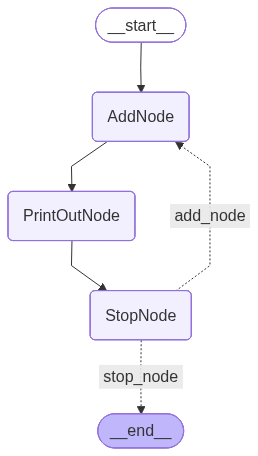

---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	AddNode(AddNode)
	PrintOutNode(PrintOutNode)
	StopNode(StopNode)
	__end__([<p>__end__</p>]):::last
	AddNode --> PrintOutNode;
	PrintOutNode --> StopNode;
	StopNode -. &nbsp;add_node&nbsp; .-> AddNode;
	StopNode -. &nbsp;stop_node&nbsp; .-> __end__;
	__start__ --> AddNode;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



In [92]:
from IPython.display import Image, display

app = workflow.compile()
display(Image(app.get_graph().draw_mermaid_png()))
print(app.get_graph().draw_mermaid())

In [97]:
app.invoke({"n":7}, config={"recursion_limit": 100})

n =  8
letter =  p
n =  9
letter =  u
n =  10
letter =  v
n =  11
letter =  k
n =  12
letter =  p
n =  13
letter =  k


{'n': 13, 'letter': 'k'}